## Hermite approximations in iResNet coordinates for various target functions

Let's start by loading necessary libraries.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import jax 
from jax import numpy as jnp
from flows.types import *
import optax
from flows.utils import *
from flows.models.linear import Linear
from flows.utils import *
import matplotlib.pyplot as plt
from functools import partial
from flows.Bases import Hermite 
from flows.bases import *

import flax.linen as nn

import pickle 
from flows.models.iresnet import InvertibleResNet
from flows.models.MLP import clip_kernel_svd_multiple
from target_functions import *
from sklearn.linear_model import LinearRegression
from flows.models.iresnet import IResNet, ActivationFunction
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Computer Modern Roman'
fontsize_label = 18
fontsize_title = fontsize_label + 1
fontsize_legend = fontsize_label - 4
# size of the ticks 
plt.rcParams['xtick.labelsize'] = fontsize_label - 5
plt.rcParams['ytick.labelsize'] = fontsize_label - 5

print(f"available devices: {jax.devices()}")
jax.config.update("jax_enable_x64", True)

available devices: [CpuDevice(id=0)]


## Approximating an algebraically decaying function

In [28]:
f = f_algebraic

x = jnp.linspace(-30.999,30.999,10000)

w = np.zeros_like(x)
dx = np.diff(x)
w[1:-1] = (dx[:-1] + dx[1:])/2
w[0] = dx[0]/2
w[-1] = dx[-1]/2
x = x[:,None]

f_ev = f(x, w)
integral = jnp.einsum('j,j->', f_ev, w)
print(f_ev[-1], integral)

2.0727462290778044e-24 0.9999999999999961


In [29]:
def Gaussian(x):
    return (jnp.exp(-x[:,0]**2)/jnp.sqrt(jnp.pi))[:, None]

integral_Gaussian = jnp.einsum('j,j->', Gaussian(x)[:,0], w)
print(integral_Gaussian)

1.0


Define the iResNet model

In [30]:
class MultipleResLin(nn.Module):
    number_of_layers: int
    dim: int
    activation: activationType=activationType.erf
    
    def setup(self):
        self.models = [InvertibleResNet([[8,8,self.dim]], lip=0.98, activation=self.activation,
                                        svd=svdType.direct) for _ in range(self.number_of_layers)]
        self.lin_model = Linear([1.]*self.dim, [0.]*self.dim)
    
    @nn.compact
    def __call__(self, x, mode=evaluationMode.direct):
        
        if mode == evaluationMode.direct:
            x = self.lin_model(x, mode=mode)
            for model_nl in self.models:
                x = model_nl(x, mode=mode)
            return x
        else:
            for model_nl in reversed(self.models):
            
                x = model_nl(x, mode=mode)
            x = self.lin_model(x, mode=mode)
            
            return x
n_layers = 10
model = MultipleResLin(n_layers, x.shape[1], activation=activationType.lipswish)


In [31]:
params = model.init(jax.random.PRNGKey(0), x, mode=evaluationMode.direct)

y_forward = model.apply(params, x, mode=evaluationMode.inverse)
y_forward_back = model.apply(params, y_forward, mode=evaluationMode.direct)
params = clip_kernel_svd_multiple(params, lipschitz_constant=0.0001) 
#full_f = full_f_algebraic

@jax.jit
def l2_error(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values, w))
    return loss

# another loss to punish more deviations in the tail 
@jax.jit
def error_tail(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values*(1+x[:,0]**2 / (true_func + 1e-30)), w))
    return loss

@jax.jit
def error_log_ratio(params, x, w):
    y   = model.apply(params, x, mode=evaluationMode.direct)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    true_func = f(x, w)

    # log g(y) = log f(x) - log|det J|
    # for perfect map: log g(y) + y²/2 = const
    log_g   = jnp.log(jnp.abs(true_func) + 1e-30) - jnp.log(det + 1e-30)
    log_gam = -0.5 * y[:, 0] ** 2   # log of unnormalised Gaussian

    # relative log error, weighted by f itself so bulk + tail both matter
    log_ratio  = (log_g - log_gam) ** 2
    loss = jnp.sqrt(jnp.einsum('i,i->', log_ratio * true_func, w))
    return loss

def total_loss(params, x, w, alpha=0.9):
    return alpha*l2_error(params, x, w) + (1-alpha)*error_tail(params, x, w)


nograd = lambda x: jax.lax.stop_gradient(x)
loss_grad_fn = jax.value_and_grad(total_loss)#l2_error)
loss_fn = total_loss#l2_error 

@jax.jit
def update_params(carry, args):
    params, opt_state, loss = carry
    loss_val, grad = loss_grad_fn(params, *args)
    updates, opt_state = optimizer.update(grad, opt_state)
    params = optax.apply_updates(params, updates)

    params = clip_kernel_svd_multiple(params, lipschitz_constant=0.9)
    return (params, opt_state, loss+loss_val), 0

learning_rate = 1e-3
n_epochs = 20000
nmax = 0


schedule = optax.cosine_decay_schedule(learning_rate, n_epochs, alpha=5e-5/learning_rate)
optimizer = optax.chain(
    #optax.clip_by_global_norm(1.0),
    optax.adam(schedule),
)
#optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(params)
losses = []
for epoch in range(1,n_epochs):
    carry = (params, opt_state, 0)
    carry, _ = update_params(carry, (nograd(x), nograd(w)))
    params, opt_state, loss = carry 
    losses.append(loss)
    if epoch % 100 == 0:
        l2_loss = l2_error(params, x, w)
        loss_tail = error_tail(params, x, w)
        print(f"Epoch: {epoch}, Loss: {loss}, L2 Loss: {l2_loss}, Tail Loss: {loss_tail}")
    


Epoch: 100, Loss: 0.5498817366920693, L2 Loss: 0.435029891760033, Tail Loss: 1.4955510500971745
Epoch: 200, Loss: 0.028173482090515595, L2 Loss: 0.02325980315597488, Tail Loss: 0.07138786641742745
Epoch: 300, Loss: 0.026918838789382487, L2 Loss: 0.022361497836171057, Tail Loss: 0.06792151910361698
Epoch: 400, Loss: 0.026809102951950037, L2 Loss: 0.022256108026345287, Tail Loss: 0.0677770041468309
Epoch: 500, Loss: 0.026732897635978282, L2 Loss: 0.022183713171655482, Tail Loss: 0.0676692304733713
Epoch: 600, Loss: 0.026684196698130786, L2 Loss: 0.02213191552997411, Tail Loss: 0.0675770075295891
Epoch: 700, Loss: 0.0266807944474023, L2 Loss: 0.022151079937738825, Tail Loss: 0.06750301883351122
Epoch: 800, Loss: 0.026583447371558492, L2 Loss: 0.02204686799788204, Tail Loss: 0.0674002465961422
Epoch: 900, Loss: 0.02652521927536736, L2 Loss: 0.02199489873600774, Tail Loss: 0.06729032224994091
Epoch: 1000, Loss: 0.026465963435850205, L2 Loss: 0.021941962234797382, Tail Loss: 0.06717296630005

In [32]:
def plot(params, x, w):
    y = model.apply(params, x, mode=evaluationMode.direct)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    plt.plot(x, true_func, label='True function')
    plt.plot(x, approx_func, label='Approximation')
    plt.legend()
    plt.show()


#plot(params, x, w)
#with open("superGaussian_params.pkl", "wb") as f:
filename = f"simulations_data/iResNet_algebraic_lipswish_nlayers_{n_layers}.pkl"
with open(filename, "wb") as f:
    pickle.dump(params, f)

det = abs_det_jac_x(model, params, jnp.array([0.]).reshape(-1,1), mode=evaluationMode.direct)
sing_loc = det

filename_save = f"simulations_data/iResNet_algebraic_lipswish_nlayers_{n_layers}.npz"
np.savez(filename_save, epochs=n_epochs, losses_nl=losses, sing_loc=sing_loc)

In [33]:
g_deriv = abs_det_jac_x(model, params, jnp.array([0.])[:,None], mode=evaluationMode.direct)
print(f"change in the location of singularity: {g_deriv}")

change in the location of singularity: [2.69419903]


## Approximating a super Gaussian function

0.0 1.0
(10000, 49)


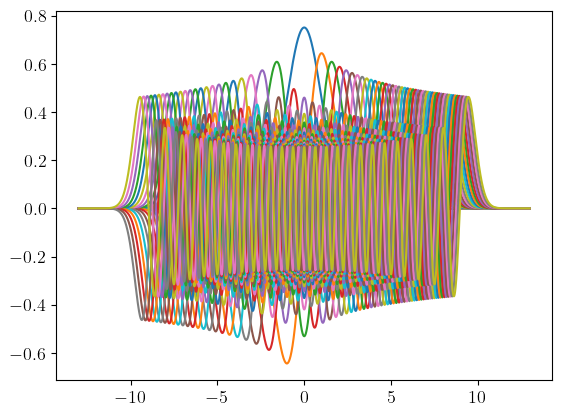

In [34]:
f = f_super_Gaussian

x = jnp.linspace(-12.999,12.999,10000)

w = np.zeros_like(x)
dx = np.diff(x)
w[1:-1] = (dx[:-1] + dx[1:])/2
w[0] = dx[0]/2
w[-1] = dx[-1]/2
x = x[:,None]

f_ev = f(x, w)
integral = jnp.einsum('j,j->', f_ev, w)
print(f_ev[-1], integral)
# plot Hermite functions
nmax = 48
# works really good
n_basis = [nmax for _ in range(x.shape[1])]
w_basis = [1 for _ in range(x.shape[1])]

basis_r = Hermite.init_basis(n_basis, w_basis, nmax, orthotype=orthoType.ortho) # 
psi_o = partial(Hermite.batch_basis_values, basis_r)  
psi_o_ev = psi_o(x)
print(psi_o_ev.shape)
psi_o_ev = jnp.einsum('jk,j->jk', psi_o_ev, jnp.exp(-x[:,0]**2/2))
plt.plot(x, psi_o_ev)


In [35]:
params = model.init(jax.random.PRNGKey(0), x, mode=evaluationMode.direct)
y_forward = model.apply(params, x, mode=evaluationMode.inverse)
y_forward_back = model.apply(params, y_forward, mode=evaluationMode.direct)
params = clip_kernel_svd_multiple(params, lipschitz_constant=0.0001) 

@jax.jit
def l2_error(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values, w))
    return loss

# another loss to punish more deviations in the tail 
@jax.jit
def error_tail(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values*(1+x[:,0]**2 / (true_func + 1e-30)), w))
    return loss

@jax.jit
def error_log_ratio(params, x, w):
    y   = model.apply(params, x, mode=evaluationMode.direct)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    true_func = f(x, w)

    # log g(y) = log f(x) - log|det J|
    # for perfect map: log g(y) + y²/2 = const
    log_g   = jnp.log(jnp.abs(true_func) + 1e-30) - jnp.log(det + 1e-30)
    log_gam = -0.5 * y[:, 0] ** 2   # log of unnormalised Gaussian

    # relative log error, weighted by f itself so bulk + tail both matter
    log_ratio  = (log_g - log_gam) ** 2
    loss = jnp.sqrt(jnp.einsum('i,i->', log_ratio * true_func, w))
    return loss

def total_loss(params, x, w, alpha=0.3):
    return alpha*l2_error(params, x, w) + (1-alpha)*error_tail(params, x, w)

    #return error_log_ratio(params, x, w)

nograd = lambda x: jax.lax.stop_gradient(x)
loss_grad_fn = jax.value_and_grad(total_loss) #l2_error)
loss_fn = total_loss #l2_error 

@jax.jit
def update_params(carry, args):
    params, opt_state, loss = carry
    loss_val, grad = loss_grad_fn(params, *args)
    updates, opt_state = optimizer.update(grad, opt_state)
    params = optax.apply_updates(params, updates)

    params = clip_kernel_svd_multiple(params, lipschitz_constant=0.9)
    return (params, opt_state, loss+loss_val), 0


learning_rate = 3e-2
n_epochs = 40000

schedule = optax.cosine_decay_schedule(learning_rate, n_epochs, alpha=5e-5/learning_rate)
optimizer = optax.chain(
    optax.adam(schedule),
)
opt_state = optimizer.init(params)
losses = []
for epoch in range(1,n_epochs):
    carry = (params, opt_state, 0)
    carry, _ = update_params(carry, (nograd(x), nograd(w)))
    params, opt_state, loss = carry 
    losses.append(loss)
    if epoch % 100 == 0:
        l2_loss = l2_error(params, x, w)
        loss_tail = error_tail(params, x, w)
        print(f"Epoch: {epoch}, Loss: {loss}, L2 Loss: {l2_loss}, Tail Loss: {loss_tail}")
    


Epoch: 100, Loss: 0.9805346381656044, L2 Loss: 0.800197513681765, Tail Loss: 1.0578271908527337
Epoch: 200, Loss: 0.9805727959620503, L2 Loss: 0.800229636438826, Tail Loss: 1.0578627216653638
Epoch: 300, Loss: 0.9805727963556546, L2 Loss: 0.8002296365853354, Tail Loss: 1.0578627219488688
Epoch: 400, Loss: 0.980572794621825, L2 Loss: 0.8002296348386797, Tail Loss: 1.0578627202163007
Epoch: 500, Loss: 0.9805727926018412, L2 Loss: 0.8002296328044248, Tail Loss: 1.0578627181984483
Epoch: 600, Loss: 0.9805727903071684, L2 Loss: 0.800229630493999, Tail Loss: 1.0578627159066532
Epoch: 700, Loss: 0.9805727877431634, L2 Loss: 0.8002296279127432, Tail Loss: 1.0578627133462117
Epoch: 800, Loss: 0.9805727849113863, L2 Loss: 0.8002296250621972, Tail Loss: 1.0578627105186513
Epoch: 900, Loss: 0.9805727818107229, L2 Loss: 0.8002296219412147, Tail Loss: 1.0578627074228348
Epoch: 1000, Loss: 0.9805727784380178, L2 Loss: 0.8002296185466077, Tail Loss: 1.0578627040556001
Epoch: 1100, Loss: 0.980572774788

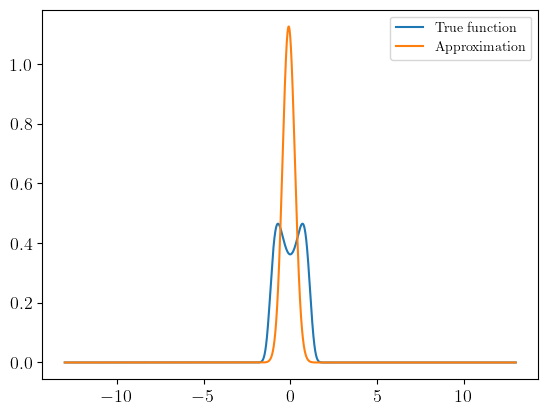

In [36]:
def plot(params, x, w):
    y = model.apply(params, x, mode=evaluationMode.direct)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    plt.plot(x, true_func, label='True function')
    plt.plot(x, approx_func, label='Approximation')
    plt.legend()
    plt.show()

plot(params, x, w)
filename = f"simulations_data/iResNet_superGaussian_lipswish_nlayers_{n_layers}.pkl"
with open(filename, "wb") as f:
    pickle.dump(params, f)
    
filename_save = f"simulations_data/iResNet_superGaussian_lipswish_nlayers_{n_layers}.npz"
np.savez(filename_save, epochs=n_epochs, losses_nl=losses,)

In [12]:
f = full_f_tanh

x = jnp.linspace(-12.999,12.999,10000)

w = np.zeros_like(x)
dx = np.diff(x)
w[1:-1] = (dx[:-1] + dx[1:])/2
w[0] = dx[0]/2
w[-1] = dx[-1]/2
x = x[:,None]

f_ev = f(x, w)
integral = jnp.einsum('j,j->', f_ev, w)
print(f_ev[-1], integral)

8.103487305413508e-38 -2.304235504800605e-16


In [13]:
#model = MultipleResLin(n_layers, x.shape[1], activation=activationType.scaled_erf)

params = model.init(jax.random.PRNGKey(0), x, mode=evaluationMode.direct)
y_forward = model.apply(params, x, mode=evaluationMode.inverse)
y_forward_back = model.apply(params, y_forward, mode=evaluationMode.direct)
params = clip_kernel_svd_multiple(params, lipschitz_constant=0.1) 
f = f_tanh

@jax.jit
def compute_coeff(params, x, w):
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)
    psi_ev = psi_o(y)
    weight = jnp.exp(-y[:,0]**2/2)  
    psi_ev = jnp.einsum('jk,j->jk', psi_ev, weight)
    approx_coeffs = jnp.einsum('j,jk,j,j->k', true_func, psi_ev, w, det)
    return approx_coeffs


@jax.jit
def l2_error(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    psi_ev = psi_o(y) #pr?
    weight = jnp.exp(-y[:,0]**2/2)  
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)
    approx_coeffs = compute_coeff(params, x, w)
    approx_func = jnp.einsum('k,jk,j,j->j', approx_coeffs, psi_ev, det, weight)

    error_values = (true_func - approx_func)**2
    #loss = jnp.mean(error_values)
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values, w))
    return loss

nograd = lambda x: jax.lax.stop_gradient(x)
loss_grad_fn = jax.value_and_grad(l2_error)
loss_fn = l2_error 

@jax.jit
def update_params(carry, args):
    params, opt_state, loss = carry
    loss_val, grad = loss_grad_fn(params, *args)
    updates, opt_state = optimizer.update(grad, opt_state)
    params = optax.apply_updates(params, updates)
    params = clip_kernel_svd_multiple(params, lipschitz_constant=0.9)
  
    return (params, opt_state, loss+loss_val), 0

learning_rate = 1e-3
n_epochs = 300
nmax = 10
# works really good
n_basis = [nmax for _ in range(x.shape[1])]
w_basis = [1 for _ in range(x.shape[1])]
# Note that when we project we need to multiply by the weights of the basis
basis_r = Hermite.init_basis(n_basis, w_basis, nmax, orthotype=orthoType.ortho) # 
psi_o = partial(Hermite.batch_basis_values, basis_r)  


schedule = optax.cosine_decay_schedule(learning_rate, n_epochs, alpha=5e-5/learning_rate)
optimizer = optax.chain(
    optax.adam(schedule),
)
opt_state = optimizer.init(params)
losses = []
for epoch in range(1,n_epochs):
    carry = (params, opt_state, 0)
    carry, _ = update_params(carry, (nograd(x), nograd(w)))
    params, opt_state, loss = carry 
    losses.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    
#with open("superGaussian_params.pkl", "wb") as f:


Epoch: 100, Loss: 5.6081769968787067e-05
Epoch: 200, Loss: 3.07908801065992e-05


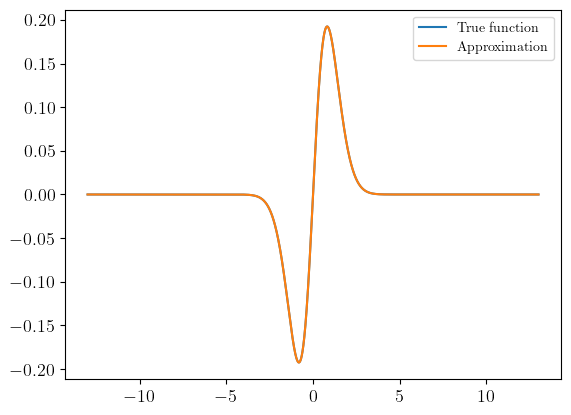

In [14]:
def plot(params, x, w):
    r = model.apply(params, x, mode=evaluationMode.direct)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    true_func = f(x,w)
    psi_ev = psi_o(r)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)
    approx_coeffs = compute_coeff(params, x, w)
    approx_func = jnp.einsum('k,jk,j,j->j', approx_coeffs, psi_ev, det, jnp.exp(-r[:,0]**2/2))
    plt.plot(x, true_func, label='True function')
    plt.plot(x, approx_func, label='Approximation')
    plt.legend()
    plt.show()
plot(params, x, w)
filename = f"simulations_data/iResNet_tanh_elu_nlayers_{n_layers}.pkl"
with open(filename, "wb") as f:
    pickle.dump(params, f)

filename_save = f"simulations_data/iResNet_tanh_elu_nlayers_{n_layers}.npz"

det = abs_det_jac_x(model, params, jnp.array([0.]).reshape(-1,1), mode=evaluationMode.direct)
sing_loc = jnp.pi/2*(det)

np.savez(filename_save, epochs=n_epochs, losses_nl=losses, sing_loc=sing_loc)



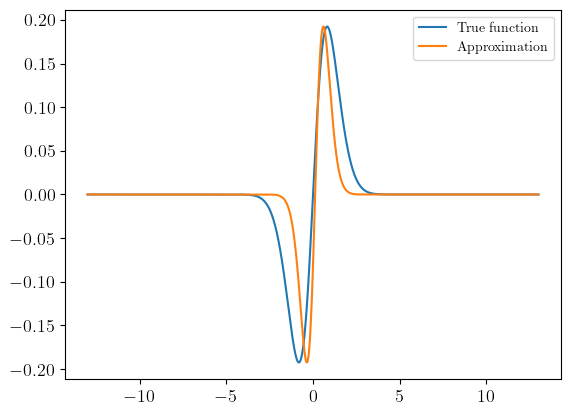

In [69]:
f = f_tanh

model2 = MultipleResLin(n_layers, x.shape[1], activation=activationType.erf)
def plot(params, x, w):
    r = model2.apply(params, x, mode=evaluationMode.direct)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    true_func = f(x,w)
    psi_ev = psi_o(r)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)
    approx_coeffs = compute_coeff(params, x, w)
    approx_func = jnp.einsum('k,jk,j,j->j', approx_coeffs, psi_ev, det, jnp.exp(-r[:,0]**2/2))
    plt.plot(x, true_func, label='True function')
    plt.plot(x, approx_func, label='Approximation')
    plt.legend()
    plt.show()
plot(params, x, w)



## Approximation using perturbed Hermite

In [37]:


def compute_coeff_uj(params, decay):
    
    if decay == "algebraic":
        x = jnp.linspace(-30.999, 30.999, 10000)
        full_f = full_f_algebraic
    
    elif decay == "superGaussian":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_super_Gaussian
    elif decay == "tanh":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_tanh
    
    w = np.zeros_like(x)
    dx = np.diff(x)
    w[1:-1] = (dx[:-1] + dx[1:])/2
    w[0] = dx[0]/2
    w[-1] = dx[-1]/2
    x = x[:,None]

    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = full_f(x,w)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    psi_ev = psi_o(y)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)
    weight = jnp.exp(-y[:,0]**2/2)  
    psi_ev = jnp.einsum('jk,j,j->jk', psi_ev, weight, det)
    approx_coeffs = jnp.einsum('j,jk,j->k', true_func, psi_ev, w)
    return approx_coeffs
   
def l2_error_uj(params, decay):    
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    if decay == "algebraic":
        x = jnp.linspace(-30.999, 30.999, 10000)
        full_f = full_f_algebraic
    elif decay == "superGaussian":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_super_Gaussian
    elif decay == "tanh":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_tanh
    
    w = np.zeros_like(x)
    dx = np.diff(x)
    w[1:-1] = (dx[:-1] + dx[1:])/2
    w[0] = dx[0]/2
    w[-1] = dx[-1]/2
    x = x[:,None]

    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = full_f(x,w)
    psi_ev = psi_o(y) #pr?
    weight = jnp.exp(-y[:,0]**2/2)  
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)

    approx_coeffs = compute_coeff_uj(params, decay)
    approx_func = jnp.einsum('k,jk,j,j->j', approx_coeffs, psi_ev, det, weight)

    error_values = (true_func - approx_func)**2
    #loss = jnp.mean(error_values)
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values, w))
    return loss


def linf_error_uj(params, decay):  
    if decay == "algebraic":
        x = jnp.linspace(-30.999, 30.999, 10000)
        full_f = full_f_algebraic
    elif decay == "superGaussian":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_super_Gaussian
    elif decay == "tanh":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_tanh
    
    w = np.zeros_like(x)
    dx = np.diff(x)
    w[1:-1] = (dx[:-1] + dx[1:])/2
    w[0] = dx[0]/2
    w[-1] = dx[-1]/2
    x = x[:,None]

    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = full_f(x,w)
    psi_ev = psi_o(y) #pr?
    weight = jnp.exp(-y[:,0]**2/2)  
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)

    approx_coeffs = compute_coeff_uj(params, decay)
    approx_func = jnp.einsum('k,jk,j,j->j', approx_coeffs, psi_ev, det, weight)

    error_values = jnp.abs(true_func - approx_func)
    loss = jnp.amax(error_values)
    return loss

n_values = np.arange(2,48,4)
list_decay = ["tanh","algebraic", "superGaussian", ]
#list_filename = [f"simulations_data/iResNet_{decay}_erf_nlayers_{n_layers}.pkl"  if decay != "tanh" else f"simulations_data/iResNet_{decay}_scaled_erf_nlayers_{n_layers}.pkl" for decay in list_decay]
list_filename = [f"simulations_data/iResNet_{decay}_lipswish_nlayers_{n_layers}.pkl" for decay in list_decay]
#n_layers = 2
#list_decay = ["algebraic"]
#list_filename = ["simulations_data/iResNet_algebraic_scaled_erf_nlayers_5.pkl"]


for decay, filename in zip(list_decay, list_filename):
    losses_nl = []
    lossesinf_nl = []
    size_basis = []
    with open(filename, "rb") as f:
        params = pickle.load(f)

    #model = MultipleResLin(n_layers, x.shape[1], activation=activationType.scaled_erf if decay == "tanh" else activationType.erf)
    model = MultipleResLin(n_layers, x.shape[1], activation=activationType.lipswish)
    for n in n_values:
        nmax = n
        n_basis = [nmax for _ in range(x.shape[1])]
        w_basis = [1 for _ in range(x.shape[1])]
        # Note that when we project we need to multiply by the weights of the basis
      
        basis_r = Hermite.init_basis(n_basis, w_basis, nmax, orthotype=orthoType.ortho) # 
        psi_o = partial(Hermite.batch_basis_values, basis_r)  

        loss = l2_error_uj(params, decay)
        loss_inf = linf_error_uj(params, decay)
        print(f"n: {n}, L2 error: {loss}, Linf error: {loss_inf}")
        losses_nl.append(loss)
        lossesinf_nl.append(loss_inf)
        size_basis.append(n+1)
        #plot_uj(params, x, w)
    if decay == "tanh":
        #filename_save =
        #f"simulations_data/losses_iResNet_{decay}_scaled_erf_nlayers_{n_layers}.npz"
        filename_save = f"simulations_data/losses_iResNet_{decay}_lipswish_nlayers_{n_layers}.npz"
    else:
        #filename_save =
        #f"simulations_data/losses_iResNet_{decay}_erf_nlayers_{n_layers}.npz"
        filename_save = f"simulations_data/losses_iResNet_{decay}_lipswish_nlayers_{n_layers}.npz"
    np.savez(filename_save, size_basis=size_basis, losses_nl=losses_nl, lossesinf_nl=lossesinf_nl)

n: 2, L2 error: 0.03549755864466676, Linf error: 0.025037662653016428
n: 6, L2 error: 0.0017388374251651342, Linf error: 0.001296856823505891
n: 10, L2 error: 9.884894380689868e-05, Linf error: 5.6161127614376416e-05
n: 14, L2 error: 2.638441160701087e-05, Linf error: 1.858901008869318e-05
n: 18, L2 error: 7.701670901200863e-06, Linf error: 5.126118904505428e-06
n: 22, L2 error: 2.288674514139974e-06, Linf error: 1.495974717734272e-06
n: 26, L2 error: 7.315738982850015e-07, Linf error: 4.7541525653727046e-07
n: 30, L2 error: 2.519248966859515e-07, Linf error: 1.6326621778139927e-07
n: 34, L2 error: 9.25406549439427e-08, Linf error: 5.986588442336016e-08
n: 38, L2 error: 3.590611942496436e-08, Linf error: 2.3194933120029848e-08
n: 42, L2 error: 1.459883779445984e-08, Linf error: 9.419504398699985e-09
n: 46, L2 error: 6.180932452101235e-09, Linf error: 3.984172609883263e-09
n: 2, L2 error: 0.004230183895220352, Linf error: 0.0038876336222755103
n: 6, L2 error: 0.0007987151313810281, Linf

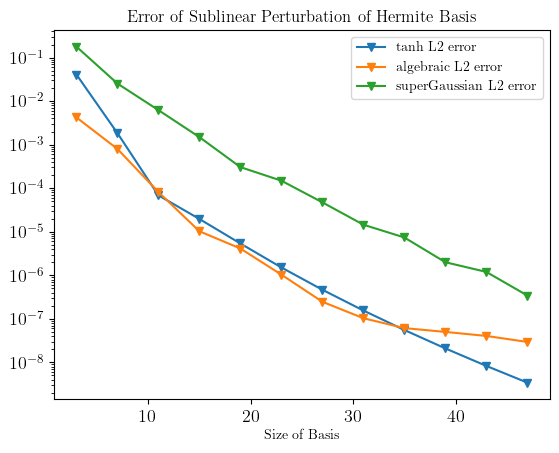

In [38]:
# Let's plot the results
list_decay = ["tanh","algebraic","superGaussian", ]
filename_list = [f"simulations_data/losses_iResNet_{decay}_lipswish_nlayers_{n_layers}.npz"  if decay != "tanh" else f"simulations_data/losses_iResNet_{decay}_scaled_erf_nlayers_{n_layers}.npz" for decay in list_decay]
for decay, filename in zip(list_decay, filename_list):
    data = np.load(filename)
    size_basis = data["size_basis"]
    losses_nl = data["losses_nl"]
    lossesinf_nl = data["lossesinf_nl"]
    plt.plot(size_basis, losses_nl, label=f"{decay} L2 error", marker='v')
    

plt.legend()
plt.yscale('log')
plt.xlabel("Size of Basis")
plt.title("Error of Sublinear Perturbation of Hermite Basis")
plt.show()

In [17]:
# Let's plot the resul  ts
list_decay = ["algebraic", "subGaussian", "superGaussian", "tanh"]
for decay in list_decay:
    data = np.load(f"simulations_data/losses_iResNet_{decay}_scaled_erf.npz")
    size_basis = data["size_basis"]
    losses_nl = data["losses_nl"]
    lossesinf_nl = data["lossesinf_nl"]
    plt.plot(size_basis, losses_nl, label=f"{decay} L2 error", marker='v')
    #plt.plot(size_basis, lossesinf_nl, label=f"{decay} Linf error", marker='v')
plt.legend()
plt.yscale('log')
plt.xlabel("Size of Basis")
plt.title("Error of Sublinear Perturbation of Hermite Basis")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'simulations_data/losses_iResNet_algebraic_scaled_erf.npz'